## Prepare input data

In [63]:
import pandas as pd
import numpy as np
import re

PET = pd.read_csv("MSR-002-001-sequences-2025-12-04.csv")
DHFR = pd.read_csv("MSR-002-002-sequences-2025-12-04.csv")
realPET = PET.copy()

realPET['substrate_name']= "PETTrimer"
realPET['substrate_smiles']= "O=C(OCCO)C1=CC=C(C(OCCOC(C2=CC=C(C(OCCOC(C3=CC=C(C(OCCO)=O)C=C3)=O)=O)C=C2)=O)=O)C=C1"
PET['substrate_name'] = "MHET"
DHFR['substrate_name'] = "DHF"
PET['substrate_smiles'] = "C1=CC(=CC=C1C(=O)O)C(=O)OCCO"
DHFR['substrate_smiles'] = "C1C(=NC2=C(N1)N=C(NC2=O)N)CNC3=CC=C(C=C3)C(=O)N[C@@H](CCC(=O)O)C(=O)O"


realPET['Name'] = realPET['Name'].str.replace(' ', '-')
DHFR['Name'] = DHFR['Name'].str.replace(' ', '-')
DHFR['Name'] = DHFR['Name'].str.replace('-', '_')
realPET['Name'] = realPET['Name'].str.replace(r'\.', 'p', regex=True)
PET['Name_clean'] = PET['Name'].str.replace(r'\.', 'p', regex=True)
DHFR['Name_clean'] = DHFR['Name'].str.replace(r'\.', 'p', regex=True)

PET['Entry'] = PET['Name_clean'] + "_" + PET['substrate_name']
DHFR['Entry'] = DHFR['Name_clean'] + "_" + DHFR['substrate_name']
realPET['Entry'] = realPET['Name'] + "_" + realPET['substrate_name']




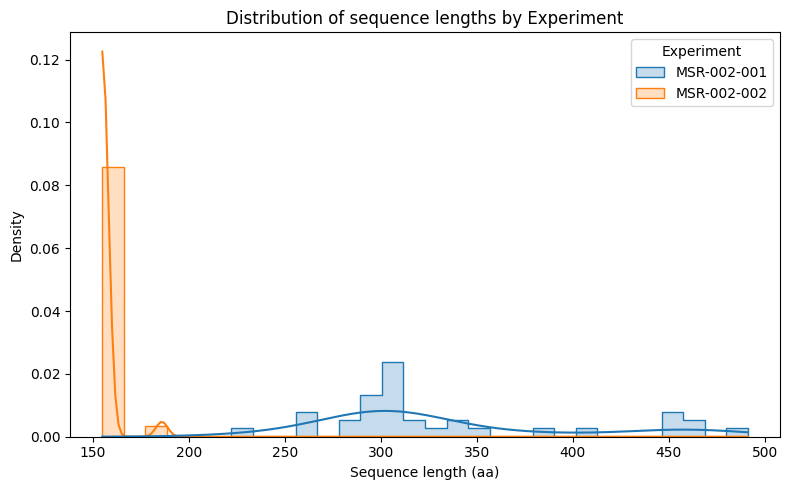

In [64]:
import seaborn as sns

df = pd.concat([realPET, PET, DHFR], ignore_index=True)

df.rename(columns={"AA Sequence": "Sequence"}, inplace=True)
df['substrate_moiety'] = None
df['cofactor_name'] = None
df['cofactor_moiety'] = None

# clean amino acid sequence
def clean_sequence(seq: str) -> str:

    if pd.isna(seq):
        return None
    seq = seq.upper()
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq)  # Keep only standard 20 amino acids
    return seq

df['Sequence'] = df['Sequence'].apply(clean_sequence)

# add sequence length column
df['seq_length'] = df['Sequence'].fillna('').map(len)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(
    data=df.dropna(subset=['seq_length']),
    x='seq_length',
    hue='Experiment',
    stat='density',
    element='step',
    common_norm=False,
    bins=30,
    kde=True,
    palette='tab10'
)
plt.xlabel('Sequence length (aa)')
plt.ylabel('Density')
plt.title('Distribution of sequence lengths by Experiment')
plt.tight_layout()
plt.show()

# df.to_pickle("MSR_input_data.pkl")

## Analyze chai docking and calculate distances between ligs

In [65]:
import pandas as pd
import sys
sys.path.insert(0, "/nvme2/helen/EnzymeStructuralFiltering/MicrosoftEnzymes")
from chai_ligand_distance import calculate_ligand_terminus_distances

results = pd.read_pickle("/nvme2/helen/EnzymeStructuralFiltering/MicrosoftEnzymes/filterzyme_output/docking/chai.pkl")

results_expanded = results.loc[results.index.repeat(5)].copy()
results_expanded['file_index'] = results_expanded.groupby('Entry').cumcount().astype(str)

results_expanded['chai_dir'] = (
    "/nvme2/helen/EnzymeStructuralFiltering/MicrosoftEnzymes/filterzyme_output/docking/chai/"
    + results_expanded ['Entry'] + "/chai/"
    + results_expanded['Entry'] + "_" + results_expanded['file_index'] + ".cif"
)

results_expanded['ligand_distances'] = results_expanded['chai_dir'].apply(calculate_ligand_terminus_distances)

results_expanded[['dist_n', 'dist_c', 'ligand_centroid', 'n_term', 'c_term']] = pd.DataFrame(
    results_expanded['ligand_distances'].tolist(),
    index=results_expanded.index
)

In [66]:
# collapse results_expanded to one row per Entry:
entry_stats = (
    results_expanded
    .groupby('Entry', as_index=False)
    .agg(
        dist_n_mean=('dist_n', 'mean'),
        dist_n_std=('dist_n', 'std'),
        dist_c_mean=('dist_c', 'mean'),
        dist_c_std=('dist_c', 'std'),
        n_models=('file_index', 'count')
    )
)

# attach representative metadata (first occurrence per Entry)
meta_cols = ['Entry', 'Experiment', 'Name', 'Name_clean', 'seq_length', 'substrate_name', 'output_dir']
meta = results_expanded.drop_duplicates(subset='Entry')[meta_cols]
entry_summary = meta.merge(entry_stats, on='Entry', how='right')


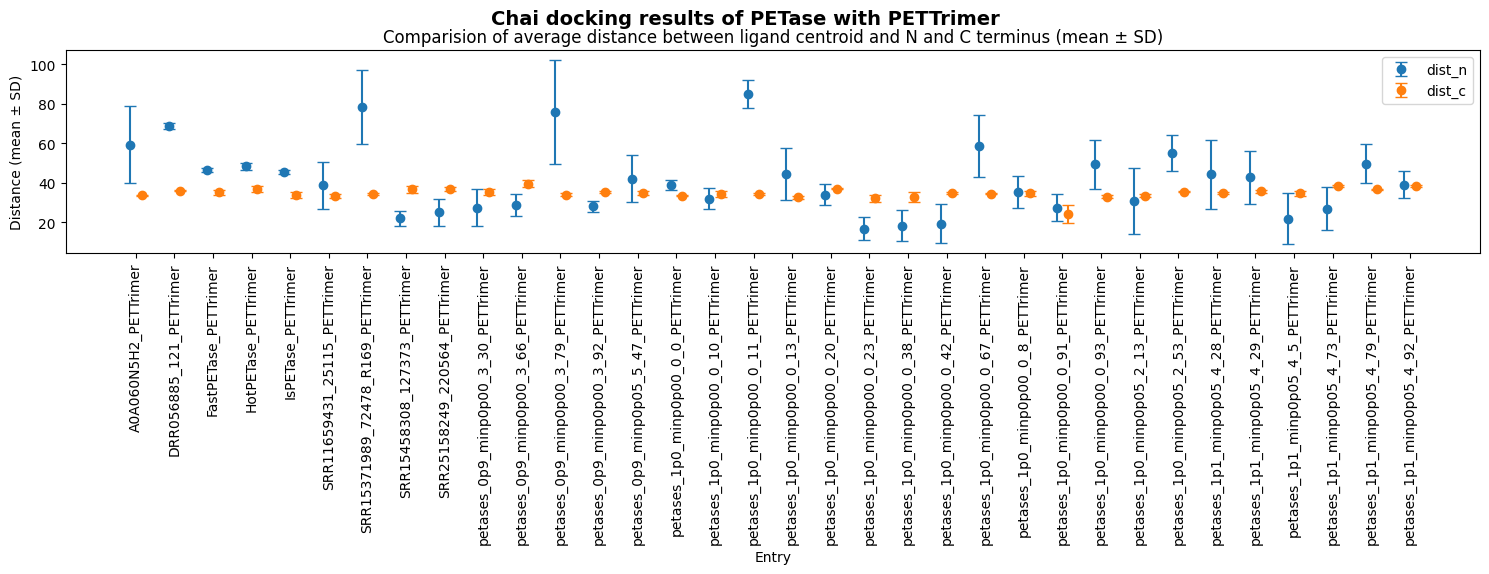

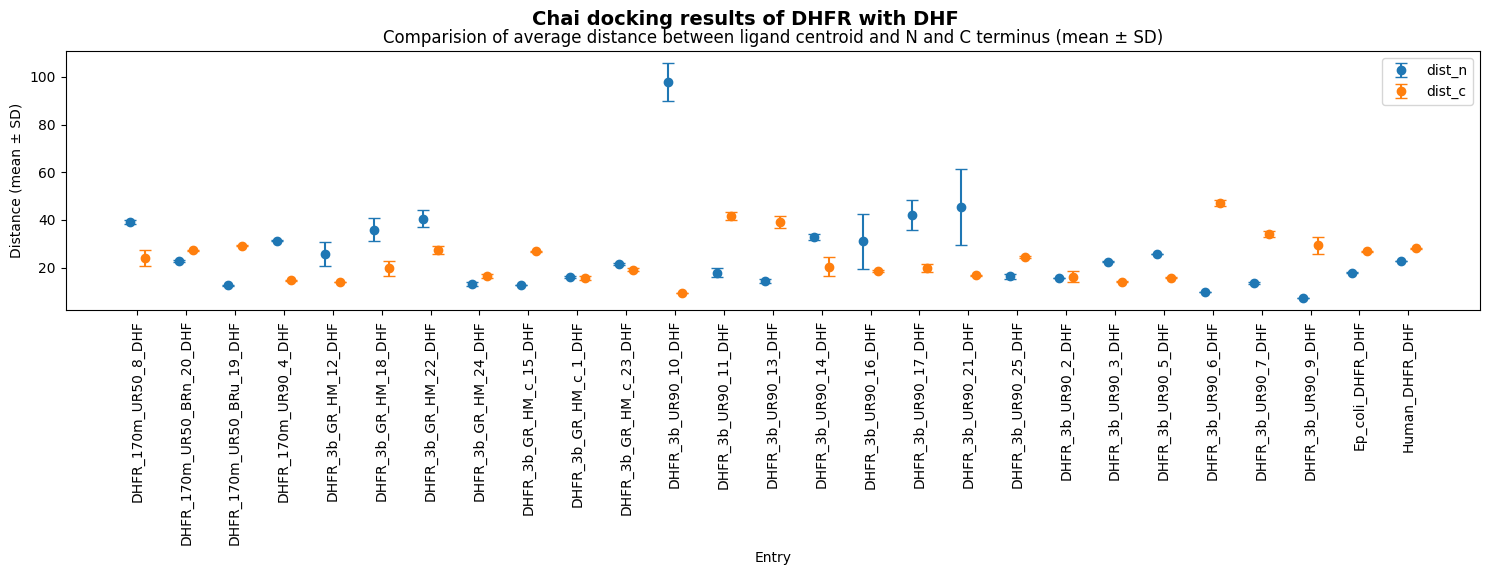

In [67]:
import matplotlib.pyplot as plt
import numpy as np


def plot_distance_summary(entry_summary, enzyme_name="PETase", substrate_name="PETTrimer"):

    # Prepare figure
    plt.figure(figsize=(15, 6))

    entries = entry_summary["Entry"]
    x = np.arange(len(entries))

    # Offsets so N and C appear side-by-side at each Entry
    offset = 0.15

    # Plot dist_n (left dot)
    plt.errorbar(
        x - offset,
        entry_summary["dist_n_mean"].to_numpy(),
        yerr=entry_summary["dist_n_std"],
        fmt='o',
        capsize=4,
        label="dist_n",
    )

    # Plot dist_c (right dot)
    plt.errorbar(
        x + offset,
        entry_summary["dist_c_mean"],
        yerr=entry_summary["dist_c_std"],
        fmt='o',
        capsize=4,
        label="dist_c",
    )

    # Formatting
    plt.xticks(x, entries, rotation=90)
    plt.xlabel("Entry")
    plt.ylabel("Distance (mean ± SD)")
    plt.title("Comparision of average distance between ligand centroid and N and C terminus (mean ± SD)")
    plt.suptitle(f"Chai docking results of {enzyme_name} with {substrate_name}", y=0.95, fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()

    plt.show()


plot_distance_summary(entry_summary[entry_summary['substrate_name'] == 'PETTrimer'])
# plot_distance_summary(entry_summary[entry_summary['substrate_name'] == 'MHET'], enzyme_name="PETase", substrate_name="MHET")
plot_distance_summary(entry_summary[entry_summary['substrate_name'] == 'DHF'], enzyme_name="DHFR", substrate_name="DHF")


## Scoring Rule for Terminus Selection

We want to choose the terminus (N or C) that is:
- Farther from the ligand on average
- More flexible / less structured (larger variation = larger std)


For each terminus (N or C), compute:

\[
\text{score} = \mu + \lambda \sigma
\]

Where:

- \( \mu \) = mean distance to the ligand  
  (`dist_n_mean` or `dist_c_mean`)
- \( \sigma \) = standard deviation of that distance  
  (`dist_n_std` or `dist_c_std`)
- \( \lambda \) = weight controlling how strongly flexibility (variance) is rewarded  
  (e.g., 0.5, 1.0, 2.0)

A larger score indicates a terminus that is both farther from the ligand and more flexible.



In [77]:
import numpy as np

lambda_weight = 1.5  # tweak this (e.g. 0.5, 1.0, 1.5)

entry_summary["dist_n_score"] = (
    entry_summary["dist_n_mean"] + lambda_weight * entry_summary["dist_n_std"]
)
entry_summary["dist_c_score"] = (
    entry_summary["dist_c_mean"] + lambda_weight * entry_summary["dist_c_std"]
)

# choose recommended terminus per Entry
def choose_term(row):
    if row["dist_n_score"] > row["dist_c_score"]:
        return "N"
    elif row["dist_c_score"] > row["dist_n_score"]:
        return "C"
    else:
        return "tie"

entry_summary["recommended_terminus"] = entry_summary.apply(choose_term, axis=1)

entry_summary["check"] = (
    (entry_summary["dist_n_mean"] - entry_summary["dist_c_mean"]).abs() < 7
)




# entry_summary[["Entry",
#                "dist_n_mean", "dist_n_std", "dist_n_score",
#                "dist_c_mean", "dist_c_std", "dist_c_score",
#                "recommended_terminus"]]


In [ ]:
#prepareoutputdata

output_df = entry_summary[entry_summary['substrate_name'] != 'MHET'].reset_index(drop=True)
output_df = output_df.drop(columns=['Name_clean', 'seq_length', 'output_dir', 'n_models', 'Entry', 'substrate_name'])
count_true = output_df["check"].sum()
print("Number of entries with |dist_n_mean - dist_c_mean| < 5 Å:", count_true)

# output_df.to_csv("MSR_enzymes_tag_position.csv")

Number of entries with |dist_n_mean - dist_c_mean| < 5 Å: 15


In [ ]:
manual_df = pd.read_csv("MSR_enzymes_tag_position_HS.csv")

manual_df

# replace recommended_terminus with manual_inspection when manual_inspection is present
mask = (
    manual_df['manual_inspection'].notna()
    & (
        manual_df['recommended_terminus'].isna()
        | (manual_df['manual_inspection'] != manual_df['recommended_terminus'])
    )
)

manual_df.loc[mask, 'recommended_terminus'] = manual_df.loc[mask, 'manual_inspection']

# flag which rows were overwritten and show a brief summary
manual_df['recommended_overwritten'] = mask
manual_df[['Name', 'recommended_terminus', 'manual_inspection', 'recommended_overwritten']]

# make sure PETase control enzymes have C-terminal tags
names = ["FastPETase", "HotPETase", "IsPETase"]
mask2 = manual_df["Name"].isin(names) & (manual_df["recommended_terminus"] == "N")
manual_df.loc[mask2, "recommended_terminus"] = "C"
manual_df.loc[mask2, "recommended_overwritten"] = True



,Name,recommended_terminus,recommended_overwritten
28,FastPETase,C,True
29,HotPETase,C,True
31,IsPETase,C,True


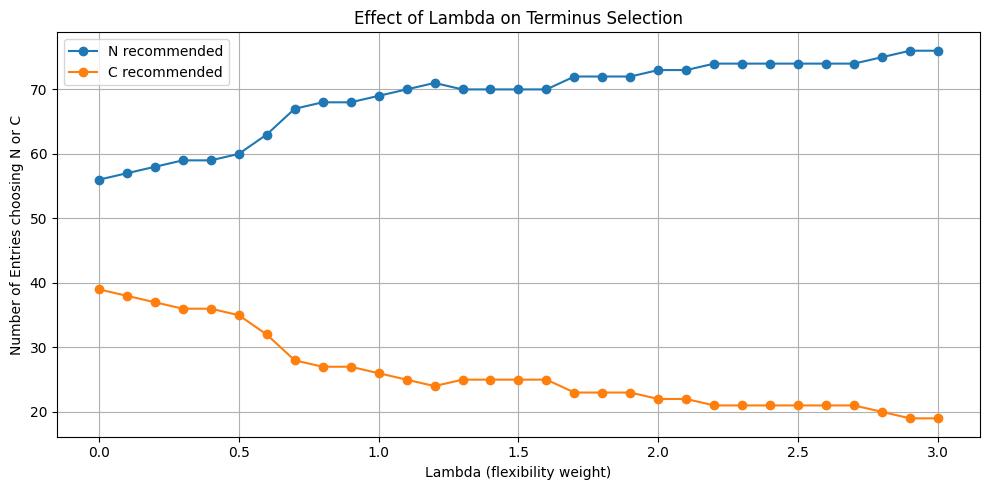

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. ]),
 [56,
  57,
  58,
  59,
  59,
  60,
  63,
  67,
  68,
  68,
  69,
  70,
  71,
  70,
  70,
  70,
  70,
  72,
  72,
  72,
  73,
  73,
  74,
  74,
  74,
  74,
  74,
  74,
  75,
  76,
  76],
 [39,
  38,
  37,
  36,
  36,
  35,
  32,
  28,
  27,
  27,
  26,
  25,
  24,
  25,
  25,
  25,
  25,
  23,
  23,
  23,
  22,
  22,
  21,
  21,
  21,
  21,
  21,
  21,
  20,
  19,
  19])

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def explore_lambda_effect(entry_summary, lambdas=None):
    """
    Tries different lambda values and plots how many Entries choose N vs C.
    """
    if lambdas is None:
        lambdas = np.linspace(0, 3, 31)  # 0.0 to 3.0 in 0.1 steps

    n_counts = []
    c_counts = []

    for lam in lambdas:
        # compute scores
        score_n = entry_summary["dist_n_mean"] + lam * entry_summary["dist_n_std"]
        score_c = entry_summary["dist_c_mean"] + lam * entry_summary["dist_c_std"]

        # recommended terminus per entry
        recommend_n = (score_n > score_c)
        recommend_c = (score_c > score_n)

        n_counts.append(recommend_n.sum())
        c_counts.append(recommend_c.sum())

    # Plot ratio or counts
    plt.figure(figsize=(10, 5))

    plt.plot(lambdas, n_counts, label="N recommended", marker='o')
    plt.plot(lambdas, c_counts, label="C recommended", marker='o')

    plt.xlabel("Lambda (flexibility weight)")
    plt.ylabel("Number of Entries choosing N or C")
    plt.title("Effect of Lambda on Terminus Selection")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return lambdas, n_counts, c_counts

explore_lambda_effect(entry_summary)